# Income and Language

## Important Column Names
- `S1902_C03_001E` the mean household income (E: estimate) for all households in that GEO_ID / Census Tract
- `S1902_C02_001M` the margin of error (M: Margin of error) for mean income for all households in that GEO_ID / Census Tract
- `S1902_C01_001E` number of households in that GEO_ID / Census Tract
- `S1903_C03_001E` the median household income (E: Estimate) for all households in that GEO_ID
- `S1903_C03_001M` the margin of error (M: Margin of error) for median income for all


In [3]:
import pandas as pd
import geopandas as gdp
import matplotlib.pyplot as plt
import glob


from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np
import joblib
from pathlib import Path

import random

# local mods
import geo_utils as geo
import clean_utils as clean

In [4]:
income_data = gdp.read_file("income_data/income_poverty.geojson")

In [5]:
income_data.columns

Index(['OBJECTID', 'FIPS', 'County', 'Tract_Name', 'Population_Total',
       'Percent_Poverty_AllPeople_Income_Below_Pov_Level',
       'Poverty_Per_Capita_Income', 'Housing_Poverty_Median_Household_Income',
       'Housing_Poverty_Mean_Household_Income', 'geometry'],
      dtype='str')

In [30]:
# focus in on the counties of interest at this point, but we could expand to all counties in the future
counties = ["DENVER", "ARAPAHOE", "DOUGLAS", "JEFFERSON", "ADAMS"]
# select a few key counties from the income data
denver_metro = income_data[income_data['County'].isin(counties)]

In [31]:
# 2015 to 2019 data
# denver_metro

<Axes: >

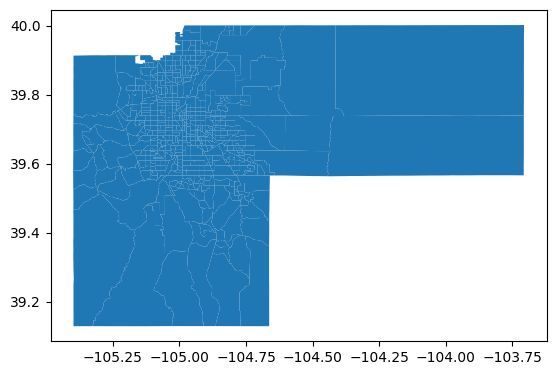

In [32]:
denver_metro.plot()

In [52]:
denver_metro.columns

Index(['OBJECTID', 'FIPS', 'County', 'Tract_Name', 'Population_Total',
       'Percent_Poverty_AllPeople_Income_Below_Pov_Level',
       'Poverty_Per_Capita_Income', 'Housing_Poverty_Median_Household_Income',
       'Housing_Poverty_Mean_Household_Income', 'geometry'],
      dtype='str')

## Next, we import the language data

In [46]:
# Path to the folder containing spreadsheet files
#path = "spreadsheets/*.csv"
#path = "test1/*.xlsx"
#path = "test3/*.xlsx"
#path = "test5/*.xlsx"
path = "data/raw/test2026-06-13/*.xlsx"
files = glob.glob(path)

# Load each file into a list of DataFrames
df_list = [pd.read_excel(file) for file in files]

# Combine them into one master DataFrame and drop na
master_df = pd.concat(df_list, ignore_index=True)
master_df = master_df.dropna(subset=["intersection","text_on_sign_exact"])
# clean the strings so they have punctuation removed and such
master_df = clean.clean_string_columns(master_df,columns=["text_on_sign_exact"])
# import additional data for mapping coordinates to intersection names
coordinates = pd.read_csv("data/raw/coordinate_dict/coordinate_dict2026-06-19.csv")
platte_river_points = pd.read_csv("data/raw/platte_points.csv")
# drop na and transition latitude and longitude strings
# to a float format
coordinates[["latitude", "longitude"]] = (
    coordinates["cd"]
    .dropna()
    .apply(geo.parse_dms_coordinate)
    .apply(pd.Series)
)
# merge the coordinate sheet with the master sheet
# so the data can be trained
training_data_raw = master_df.merge(
    coordinates[["intersection", "latitude", "longitude", "zip", "city"]],
    on="intersection",
    how="left"
)
training_data_raw.to_csv("training_data_raw.csv")

# create a dataframe that has one row per instersection with
# all of the text combined for that intersection
intersection_df = (
    training_data_raw
    .groupby("intersection")
    .agg({
        "text_on_sign_exact": " ".join,
        "latitude": "first",
        "longitude": "first",
        "zip": "first",
        "city": "first"
    })
    .reset_index()
    .rename(columns={"text_on_sign_exact": "text_blob"})
)

In [49]:
# export missing coordinates to ensure that we can go back and manually add them in if needed
missing_coords = intersection_df[intersection_df["latitude"].isna()]
if not missing_coords.empty:
    missing_coords.to_csv("missing_coords.csv")
else:
    print("No missing coordinates to export.")

No missing coordinates to export.


## Logic for Census Data
if the intersecton is completely within the perimeter of one section, use the income of that section (Census Tract?)
if the intersecton is split across two intersections, leverage both sections 
if the intersecton is split across three instersections, leverage the three sections
if the intersecton is split across four intersections, leverage all four sections